# What sets the price of an Athens Airbnb?

Predict nightly prices for Athens listings and describe how price changes with distance from the Acropolis.

Data: Inside Airbnb detailed listings for Athens, scraped 29 June 2026. Prices in EUR. These are **asking prices from a single quote per listing**, not prices guests paid.

Two targets, compared throughout:

- `price_list`: the pre-discount nightly quote rate (quote subtotal / nights), before any explicit discount, taxes or fees.
- `price_quoted`: the per-night price Airbnb showed, which can include an explicit discount (mostly labelled "Special offer") or taxes.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.features import add_targets, add_features

FIG_DIR = ROOT / "reports" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
TARGETS = ["price_list", "price_quoted"]

## 1. Load

In [2]:
raw = pd.read_csv(ROOT / "data" / "listings.csv")
df = add_features(add_targets(raw))
print(raw.shape)

(14337, 90)


## 2. Clean
The same rows are used for both targets so the comparison is fair.

In [3]:
n0 = len(df)
missing = df[TARGETS].isna().any(axis=1).sum()
df = df.dropna(subset=TARGETS)
low = 20
high = df["price_list"].quantile(0.99)
out_range = (~df[TARGETS].apply(lambda s: s.between(low, high)).all(axis=1)).sum()
df = df[df[TARGETS].apply(lambda s: s.between(low, high)).all(axis=1)].reset_index(drop=True)
print(f"Start {n0} | missing a target {missing} | outside EUR {low}-{high:.0f} {out_range} | kept {len(df)}")

Start 14337 | missing a target 192 | outside EUR 20-732 147 | kept 13998


## 3. How different are the two targets?

In [4]:
ratio = df["price_quoted"] / df["price_list"]
summary = pd.Series({
    "share with an explicit discount": df["has_discount"].mean(),
    "share where quoted differs from list by >1%": (~np.isclose(ratio, 1, rtol=0.01)).mean(),
    "median quoted/list where they differ": ratio[~np.isclose(ratio, 1, rtol=0.01)].median(),
}).round(3)
summary

share with an explicit discount                0.117
share where quoted differs from list by >1%    0.201
median quoted/list where they differ           0.925
dtype: float64

In [5]:
import json
from collections import Counter
labels_seen = Counter()
# Read labels from the raw file: add_features drops the quote JSON as a leakage guard.
for r in raw["price_quote_raw"].dropna():
    for item in json.loads(r)["quote"].get("raw_price_line_items") or []:
        if item.get("item_type") == "discount_amount":
            labels_seen[item.get("description")] += 1
pd.Series(labels_seen, name="discount line items").sort_values(ascending=False)

Special offer             1313
Long stay discount         157
Weekly stay discount       114
Early booking discount      98
Monthly stay discount       34
Name: discount line items, dtype: int64

## 4. Features

Size, location, quality, host behaviour, plus **quote conditions**: lead time, quoted stay length and check-in month. Prices come from quotes for different dates and stay lengths, so the model needs to see those.

Never used: `price_quote_total_price`, `price_quote_price_per_night`, `price_quote_raw`, `estimated_revenue_l365d` (all are the price or calculated from it). `has_discount` is also excluded because it is part of how `price_quoted` is built. `instant_bookable` is blank in this scrape.

`property_type` (grouped) is a model feature, so the models can tell a rental unit from a hotel room or a serviced apartment.

In [6]:
NUMERIC = ["km_acropolis", "km_syntagma", "accommodates", "bedrooms", "beds", "bathrooms",
           "minimum_nights", "number_of_reviews", "reviews_per_month", "number_of_reviews_ltm",
           "review_scores_rating", "review_scores_location", "host_is_superhost",
           "calculated_host_listings_count", "availability_365", "is_multi_host",
           "lead_days", "quote_nights", "checkin_month"]
# Property types with fewer than 30 listings are grouped as "Other".
pt_counts = df["property_type"].value_counts()
df["property_type_grp"] = df["property_type"].where(df["property_type"].map(pt_counts) >= 30, "Other")
CATEGORICAL = ["room_type", "neighbourhood", "property_type_grp"]
BASE_CATEGORICAL = ["room_type", "neighbourhood"]
X = df[NUMERIC + CATEGORICAL].copy()
for c in CATEGORICAL:
    X[c] = X[c].astype("category")
groups = df["host_id"].values
print(X.shape)

(13998, 22)


## 5. Five-fold cross-validation, grouped by host

Each host's listings sit entirely in one fold, because multi-listing hosts often copy prices. We report the mean and spread across folds, not a single split.

In [7]:
def make_rf(cats=None):
    cats = cats or CATEGORICAL
    return Pipeline([
        ("prep", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore"), cats),
            ("num", SimpleImputer(strategy="median"), NUMERIC)])),
        ("model", RandomForestRegressor(n_estimators=200, min_samples_leaf=3, max_features=0.5,
                                        n_jobs=-1, random_state=SEED))])

def make_lgbm():
    return LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31,
                         min_child_samples=20, random_state=SEED, verbose=-1)

def baseline(train, test, target):
    t = train.assign(y=train[target])
    look = t.groupby(["neighbourhood", "room_type"], observed=True)["y"].median()
    fall = t.groupby("room_type", observed=True)["y"].median()
    keys = zip(test["neighbourhood"], test["room_type"])
    return np.array([look.get(k, fall.get(k[1], t["y"].median())) for k in keys], dtype=float)

cv = GroupKFold(n_splits=5)
fold_rows, oof = [], {}
for target in TARGETS:
    y = np.log1p(df[target].values)
    oof[target] = {m: np.zeros(len(df)) for m in ["Random Forest", "LightGBM"]}
    for k, (tr, te) in enumerate(cv.split(X, y, groups)):
        actual = df[target].values[te]
        preds = {"Baseline (median)": baseline(df.iloc[tr], df.iloc[te], target)}
        for name, make in [("Random Forest", make_rf), ("LightGBM", make_lgbm)]:
            m = make().fit(X.iloc[tr], y[tr])
            preds[name] = np.expm1(m.predict(X.iloc[te]))
            oof[target][name][te] = preds[name]
        for name, p in preds.items():
            fold_rows.append({"target": target, "model": name, "fold": k,
                              "MAE": mean_absolute_error(actual, p)})

folds = pd.DataFrame(fold_rows)
cv_table = folds.groupby(["target", "model"])["MAE"].agg(["mean", "std", "min", "max"]).round(2)
cv_table

mean   std    min    max
target       model                                       
price_list   Baseline (median)  50.19  2.74  45.96  53.46
             LightGBM           35.10  1.96  33.29  37.50
             Random Forest      35.49  2.19  33.32  38.35
price_quoted Baseline (median)  48.84  2.70  44.63  51.70
             LightGBM           34.35  2.17  32.02  36.70
             Random Forest      34.67  2.20  32.26  37.00

In [8]:
# Is one model really better? Compare per fold.
w = folds.pivot_table(index=["target", "fold"], columns="model", values="MAE")
(w["LightGBM"] - w["Random Forest"]).groupby("target").agg(["mean", "min", "max"]).round(2)

,mean,min,max
target,,,
price_list,-0.40,-0.84,0.07
price_quoted,-0.31,-0.36,-0.24


### Does property type help?

Same folds, `price_list`, with and without `property_type_grp`. Negative = adding property type lowers the error.

In [9]:
y = np.log1p(df["price_list"].values)
X_base = df[NUMERIC + BASE_CATEGORICAL].copy()
for c in BASE_CATEGORICAL:
    X_base[c] = X_base[c].astype("category")
abl = []
for k, (tr, te) in enumerate(cv.split(X, y, groups)):
    actual = df["price_list"].values[te]
    for name, make_with, make_without in [
        ("Random Forest", lambda: make_rf(), lambda: make_rf(BASE_CATEGORICAL)),
        ("LightGBM", make_lgbm, make_lgbm)]:
        with_pt = mean_absolute_error(actual, np.expm1(make_with().fit(X.iloc[tr], y[tr]).predict(X.iloc[te])))
        no_pt = mean_absolute_error(actual, np.expm1(make_without().fit(X_base.iloc[tr], y[tr]).predict(X_base.iloc[te])))
        abl.append({"model": name, "fold": k, "with property type": with_pt, "without": no_pt, "change": with_pt - no_pt})
abl = pd.DataFrame(abl)
abl.groupby("model")[["without", "with property type", "change"]].agg(["mean", "min", "max"]).round(2)

without               with property type               change  \
                 mean    min    max               mean    min    max   mean   
model                                                                         
LightGBM        35.15  33.27  37.37              35.10  33.29  37.50  -0.05   
Random Forest   35.49  33.28  38.34              35.49  33.32  38.35   0.00   

                           
                min   max  
model                      
LightGBM      -0.27  0.13  
Random Forest -0.13  0.05

## 6. Where is the model wrong? Error by price band (list-rate target, out-of-fold)

In [10]:
best = cv_table.loc["price_list", "mean"].drop("Baseline (median)").idxmin()
pred = oof["price_list"][best]
actual = df["price_list"].values
band = pd.cut(actual, [0, 60, 100, 150, 250, np.inf], labels=["<60", "60-100", "100-150", "150-250", "250+"])
by_band = pd.DataFrame({"band": band, "abs_err": np.abs(pred - actual), "pct_err": np.abs(pred - actual) / actual})
by_band = by_band.groupby("band", observed=True).agg(listings=("abs_err", "size"),
                                                     MAE=("abs_err", "mean"),
                                                     MAPE=("pct_err", "mean")).round(3)
print("Model:", best); by_band

Model: LightGBM


,listings,MAE,MAPE
band,,,
<60,1223,21.908,0.488
60-100,5078,17.834,0.224
100-150,4241,23.580,0.194
150-250,2350,48.292,0.253
250+,1106,145.048,0.370


### The cheapest listings: what are they, and where is the model off?

These listings were selected for having low actual prices, so some over-prediction is expected: models pull extreme values toward typical ones. The table shows the pattern; it does not identify the cause.

In [11]:
cheap = pd.DataFrame({"property_type": df["property_type_grp"], "actual": actual, "pred": pred})[actual < 60]
cheap["pct_err"] = np.abs(cheap["pred"] - cheap["actual"]) / cheap["actual"]
cheap["over_predicted"] = cheap["pred"] > cheap["actual"]
cheap.groupby("property_type").agg(listings=("actual", "size"), median_rate=("actual", "median"),
                                   MAPE=("pct_err", "mean"), share_over_predicted=("over_predicted", "mean")
                                   ).sort_values("listings", ascending=False).head(10).round(2)

,listings,median_rate,MAPE,share_over_predicted
property_type,,,,
Entire rental unit,552,53.64,0.45,0.98
Entire condo,240,54.97,0.41,0.98
Private room in rental unit,162,42.46,0.27,0.63
Private room in condo,97,39.00,0.26,0.84
Other,70,43.10,1.72,0.93
Entire home,24,57.06,0.52,1.00
Room in hotel,22,55.90,0.40,0.95
Private room in serviced apartment,16,29.67,1.30,1.00
Entire loft,6,51.36,0.56,1.00


## 7. Price gradient by distance from the Acropolis (entire homes)

Two views:

- **Raw:** median list rate per distance band. Listings differ in size and type across bands, so this mixes location with everything else.
- **Adjusted:** a log-linear regression with distance bands plus controls for size, quality, property type, host behaviour and quote conditions. 95% intervals come from resampling hosts 300 times.

Both are compared with the 3-5 km band. Even the adjusted view is an **association**: unobserved differences such as views, renovation or amenities can still play a part.

In [12]:
h = df[df["room_type"] == "Entire home/apt"].copy().reset_index(drop=True)
edges = [0, 0.5, 1, 1.5, 2, 3, 5, np.inf]
labels = ["<0.5", "0.5-1", "1-1.5", "1.5-2", "2-3", "3-5", "5+"]
h["band"] = pd.cut(h["km_acropolis"], edges, labels=labels)
REF = "3-5"

raw_med = h.groupby("band", observed=True)["price_list"].median()
raw_pct = (raw_med / raw_med[REF] - 1) * 100

top_types = h["property_type"].value_counts().index[:8]
ctrl = pd.DataFrame({
    "log_accommodates": np.log(h["accommodates"].clip(lower=1)),
    "bedrooms": h["bedrooms"], "bathrooms": h["bathrooms"],
    "review_scores_rating": h["review_scores_rating"],
    "log_reviews": np.log1p(h["number_of_reviews"]),
    "host_is_superhost": h["host_is_superhost"],
    "log_host_listings": np.log(h["calculated_host_listings_count"].clip(lower=1)),
    "availability_365": h["availability_365"] / 365,
    "minimum_nights": h["minimum_nights"], "quote_nights": h["quote_nights"],
    "lead_days": h["lead_days"] / 30, "summer_checkin": h["checkin_month"].isin([6, 7, 8]).astype(int),
})
for c in ["bedrooms", "bathrooms", "review_scores_rating"]:
    ctrl[c + "_missing"] = ctrl[c].isna().astype(int)
    ctrl[c] = ctrl[c].fillna(ctrl[c].median())
ptype = pd.get_dummies(h["property_type"].where(h["property_type"].isin(top_types), "other"),
                       prefix="pt", drop_first=True, dtype=float)
bands = pd.get_dummies(h["band"], dtype=float).drop(columns=REF)
design = pd.concat([pd.Series(1.0, index=h.index, name="const"), bands, ctrl, ptype], axis=1).astype(float)
yv = np.log(h["price_list"].values)
A = design.values
band_cols = list(bands.columns)
idx = [design.columns.get_loc(c) for c in band_cols]

def fit(rows):
    beta, *_ = np.linalg.lstsq(A[rows], yv[rows], rcond=None)
    return beta[idx]

point = (np.exp(fit(np.arange(len(h)))) - 1) * 100
rng = np.random.default_rng(SEED)
hosts = h["host_id"].values
by_host = pd.Series(np.arange(len(h))).groupby(hosts).apply(np.array)
boots = []
for _ in range(300):
    pick = rng.choice(len(by_host), len(by_host), replace=True)
    rows = np.concatenate(by_host.values[pick])
    boots.append((np.exp(fit(rows)) - 1) * 100)
lo, hi = np.percentile(boots, [2.5, 97.5], axis=0)

grad = pd.DataFrame({"listings": h["band"].value_counts().reindex(labels),
                     "raw median EUR": raw_med.round(0),
                     "raw % vs 3-5 km": raw_pct.round(0),
                     "adjusted % vs 3-5 km": pd.Series(point, band_cols).round(0),
                     "95% low": pd.Series(lo, band_cols).round(0),
                     "95% high": pd.Series(hi, band_cols).round(0)}).reindex(labels)
grad.loc[REF, ["adjusted % vs 3-5 km", "95% low", "95% high"]] = 0
grad

,listings,raw median EUR,raw % vs 3-5 km,adjusted % vs 3-5 km,95% low,95% high
<0.5,566,173.0,108.0,91.0,82.0,100.0
0.5-1,3794,131.0,57.0,56.0,51.0,61.0
1-1.5,2274,104.0,25.0,26.0,22.0,30.0
1.5-2,2528,100.0,20.0,19.0,15.0,23.0
2-3,1940,93.0,12.0,9.0,5.0,13.0
3-5,1763,83.0,0.0,0.0,0.0,0.0
5+,122,83.0,-0.0,-3.0,-9.0,3.0


### Robustness: does the under-500 m estimate survive other choices?

The 95% interval above only covers host-resampling noise **within one regression**. Here the same estimate is refit under different controls and price cutoffs. `amenities_count` (number of listed amenities) is a rough proxy for the amenities the main model leaves out.

Note on cutoffs: `p95` and `p97.5` are percentiles of the homes left *after* the main trimming (EUR 20 to the overall 99th percentile). So "EUR 20 to p95" excludes homes above EUR 302, about 6% of eligible entire homes before trimming, not exactly 5%.

Reading the table: "no controls" reproduces the raw gap (+108%). The adjusted specifications range from +77% to +92%.

In [13]:
h["amenities_count"] = h["amenities"].map(lambda s: len(json.loads(s)) if isinstance(s, str) else np.nan)
SIZE = ["log_accommodates", "bedrooms", "bathrooms", "bedrooms_missing", "bathrooms_missing"]
specs = {
    "no controls": [],
    "size only": SIZE,
    "main specification": list(ctrl.columns) + list(ptype.columns),
    "main + amenities count": list(ctrl.columns) + list(ptype.columns) + ["amenities_count"],
}
full = pd.concat([ctrl, ptype, h[["amenities_count"]].fillna(h["amenities_count"].median())], axis=1)

def band_effects(controls, mask):
    D = pd.concat([pd.Series(1.0, index=h.index, name="const"), bands, full[controls]], axis=1).astype(float).values[mask]
    beta, *_ = np.linalg.lstsq(D, yv[mask], rcond=None)
    return (np.exp(beta[1:1 + len(band_cols)]) - 1) * 100

rows = []
everything = np.ones(len(h), dtype=bool)
for name, cols in specs.items():
    rows.append({"variant": name, "cutoff": "EUR 20 to p99"} | dict(zip(band_cols, band_effects(cols, everything))))
main_cols = specs["main specification"]
for label, lo_c, q in [("EUR 20 to p95", 20, 0.95), ("EUR 30 to p99", 30, 0.99), ("EUR 20 to p97.5", 20, 0.975)]:
    m = (h["price_list"] >= lo_c) & (h["price_list"] <= h["price_list"].quantile(q))
    rows.append({"variant": "main specification", "cutoff": label} | dict(zip(band_cols, band_effects(main_cols, m.values))))
robust = pd.DataFrame(rows)[["variant", "cutoff", "<0.5", "0.5-1", "1-1.5"]].round(0)
robust

,variant,cutoff,<0.5,0.5-1,1-1.5
0,no controls,EUR 20 to p99,108.0,62.0,29.0
1,size only,EUR 20 to p99,89.0,56.0,25.0
2,main specification,EUR 20 to p99,91.0,56.0,26.0
3,main + amenities count,EUR 20 to p99,92.0,57.0,25.0
4,main specification,EUR 20 to p95,77.0,49.0,23.0
5,main specification,EUR 30 to p99,88.0,54.0,25.0
6,main specification,EUR 20 to p97.5,84.0,52.0,25.0


In [14]:
adjusted = robust[robust["variant"] != "no controls"]
print(f"Under 500 m, adjusted specifications: {adjusted['<0.5'].min():.0f}% to {adjusted['<0.5'].max():.0f}% "
      f"(no controls: {robust.loc[robust['variant'] == 'no controls', '<0.5'].iloc[0]:.0f}%)")
print(f"0.5 to 1 km, adjusted specifications: {adjusted['0.5-1'].min():.0f}% to {adjusted['0.5-1'].max():.0f}%")

Under 500 m, adjusted specifications: 77% to 92% (no controls: 108%)
0.5 to 1 km, adjusted specifications: 49% to 57%


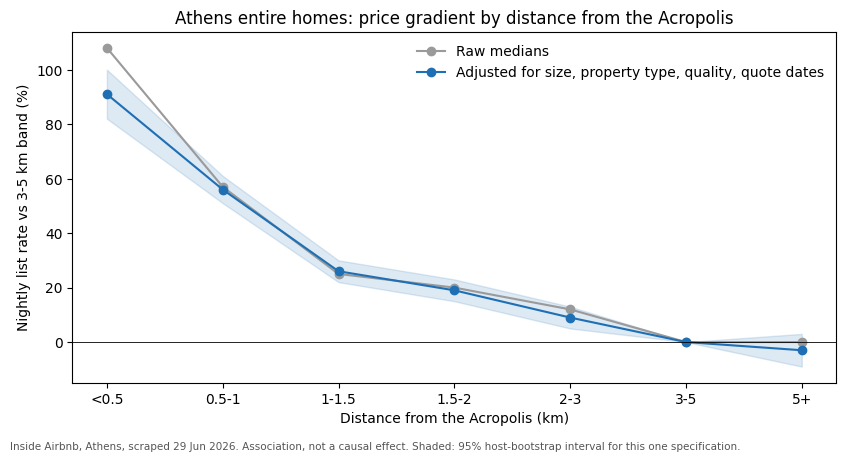

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
x = np.arange(len(labels))
ax.plot(x, grad["raw % vs 3-5 km"], marker="o", color="#9a9a9a", label="Raw medians")
adj = grad["adjusted % vs 3-5 km"].astype(float)
ax.plot(x, adj, marker="o", color="#1f6fb4", label="Adjusted for size, property type, quality, quote dates")
ax.fill_between(x, grad["95% low"].astype(float), grad["95% high"].astype(float), color="#1f6fb4", alpha=0.15)
ax.axhline(0, color="black", lw=0.6)
ax.set_xticks(x, labels)
ax.set_xlabel("Distance from the Acropolis (km)")
ax.set_ylabel("Nightly list rate vs 3-5 km band (%)")
ax.set_title("Athens entire homes: price gradient by distance from the Acropolis")
ax.legend(frameon=False)
fig.text(0.01, 0.01, "Inside Airbnb, Athens, scraped 29 Jun 2026. Association, not a causal effect. Shaded: 95% host-bootstrap interval for this one specification.",
         fontsize=7.5, color="#555")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig(FIG_DIR / "acropolis_gradient.png", dpi=200)
plt.show()

## 8. Possibly underpriced entire homes

Out-of-fold predictions of the list rate. Gap = how far the asking rate sits **below the prediction**, as a share of the prediction:
`(predicted - asking) / predicted`. A EUR 100 listing predicted at EUR 140 is 28.6% below.

A large gap means "lower than similar listings", not proof of lost revenue.

In [16]:
# Thresholds use unrounded predictions; rounding happens only for display.
df["predicted_list"] = oof["price_list"][best]
df["below_pred_pct"] = (df["predicted_list"] - df["price_list"]) / df["predicted_list"] * 100
homes = df[(df["room_type"] == "Entire home/apt") & (df["number_of_reviews"] >= 10)]
for cut in [20, 30, 40]:
    n = (homes["below_pred_pct"] > cut).sum()
    print(f"{cut}%+ below prediction: {n} of {len(homes)} ({n/len(homes):.1%})")
# Aggregates only. Single listings are never shown: neighbourhood, type and exact price
# together can point at an identifiable host (see DATA_PROTECTION.md).
# Neighbourhoods with fewer than 5 flagged homes are merged, like the demo map's 5-home rule.
flag = homes[homes["below_pred_pct"] > 40]
counts = flag["neighbourhood"].value_counts()
area = flag["neighbourhood"].where(flag["neighbourhood"].map(counts) >= 5, "Other (fewer than 5 each)")
(flag.assign(area=area).groupby("area")
     .agg(flagged=("price_list", "size"), median_asking=("price_list", "median"),
          median_predicted=("predicted_list", "median"))
     .sort_values("flagged", ascending=False).round(0))

20%+ below prediction: 1805 of 8245 (21.9%)
30%+ below prediction: 760 of 8245 (9.2%)
40%+ below prediction: 250 of 8245 (3.0%)


,flagged,median_asking,median_predicted
area,,,
ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,70,77.0,141.0
Other (fewer than 5 each),42,59.0,107.0
ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ,31,79.0,145.0
ΝΕΟΣ ΚΟΣΜΟΣ,18,56.0,120.0
ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,13,49.0,92.0
ΑΚΡΟΠΟΛΗ,12,132.0,223.0
ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ,11,122.0,232.0
ΚΕΡΑΜΕΙΚΟΣ,11,56.0,100.0
ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,10,89.0,158.0
